In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline


In [89]:
df = pd.read_excel("titanic.xls")
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [20]:
df["deck"] = df["cabin"].str[0] if df["cabin"].str != "nan" else None

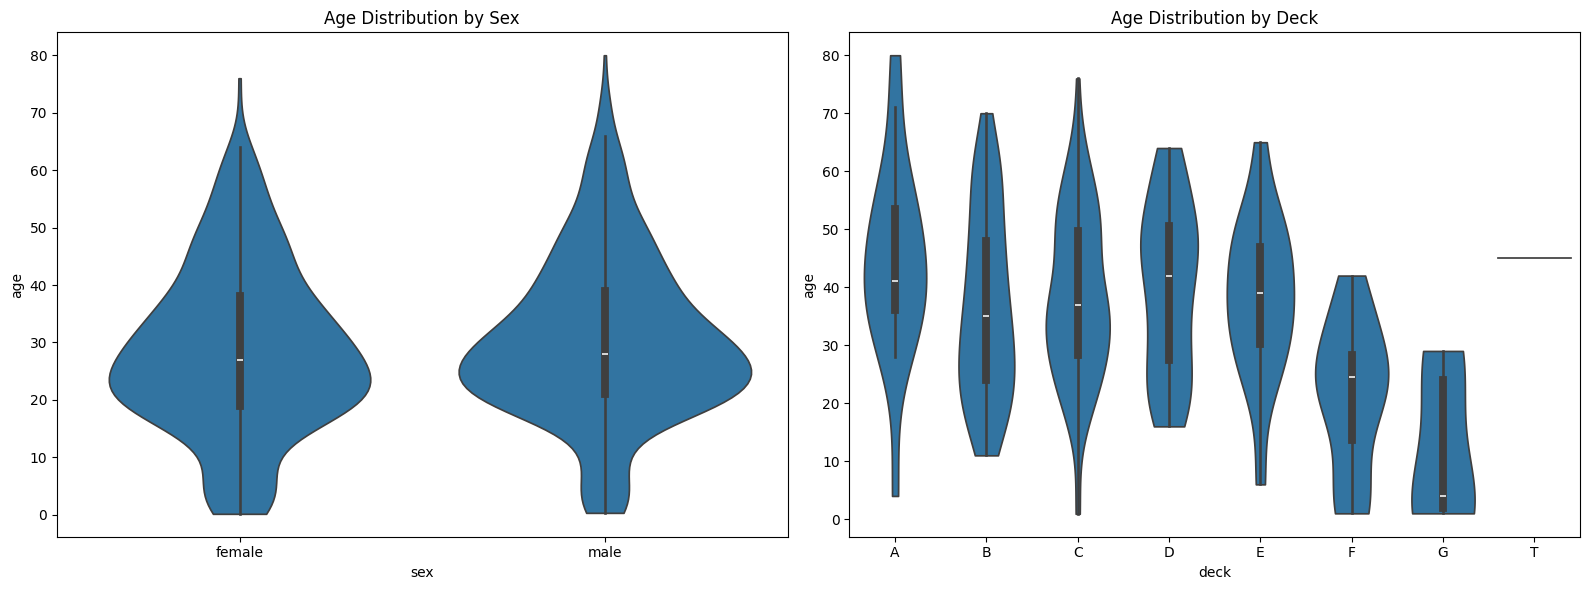

In [28]:
ig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. הגרף הראשון (גיל לפי מין) מנותב לאזור הציור השמאלי (axes[0])
sns.violinplot(data=df, x='sex', y='age', cut=0, ax=axes[0])
axes[0].set_title("Age Distribution by Sex")

# 3. הגרף השני (גיל לפי סיפון) מנותב לאזור הציור הימני (axes[1])
# חילצתי את פקודת המיון למשתנה נפרד רק כדי שהקוד יהיה יותר קריא ומסודר
deck_order = sorted(df['deck'].dropna().unique())
sns.violinplot(data=df, x='deck', y='age', order=deck_order, cut=0, ax=axes[1])
axes[1].set_title("Age Distribution by Deck")

# 4. סידור מרווחים אוטומטי והצגה
plt.tight_layout()
plt.show()

In [29]:
df["last_name"] = df["name"].str.split(",").str[0]

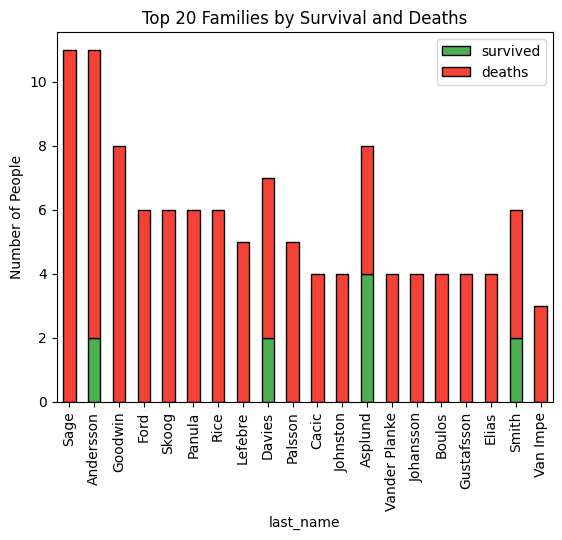

In [37]:
# 1. קבוצה לפי שם משפחה - מחשבים גם את סך השורדים וגם את גודל המשפחה ביחד
grouped_df = (
    df.groupby("last_name")
    .agg(
        survived=("survived", "sum"),
        total_members_of_family=("survived", "size"),  # size נותן את כמות השורות בקבוצה
    )
    .reset_index()
)

# 2. חישוב המתים
grouped_df["deaths"] = (
    grouped_df["total_members_of_family"] - grouped_df["survived"]
)

# 3. מיון לפי כמות המתים והפיכת השם לאינדקס לצורך הגרף
grouped_df = grouped_df.sort_values("deaths", ascending=False).set_index(
    "last_name"
)

# 4. ציור הגרף (לקחת את ה-20 הראשונים)
# הערה: עדיף להציג את "survived" ו-"deaths" כדי שהם ישלימו ביחד ל-total, 
# אם תציג את total ו-deaths אחד על השני ה-total יבלע את ה-deaths או יציג מספרים כפולים.
grouped_df[["survived", "deaths"]].head(20).plot(
    kind="bar", stacked=True, color=["#4CAF50", "#F44336"], edgecolor="black"
)

plt.ylabel("Number of People")
plt.title("Top 20 Families by Survival and Deaths")
plt.show()

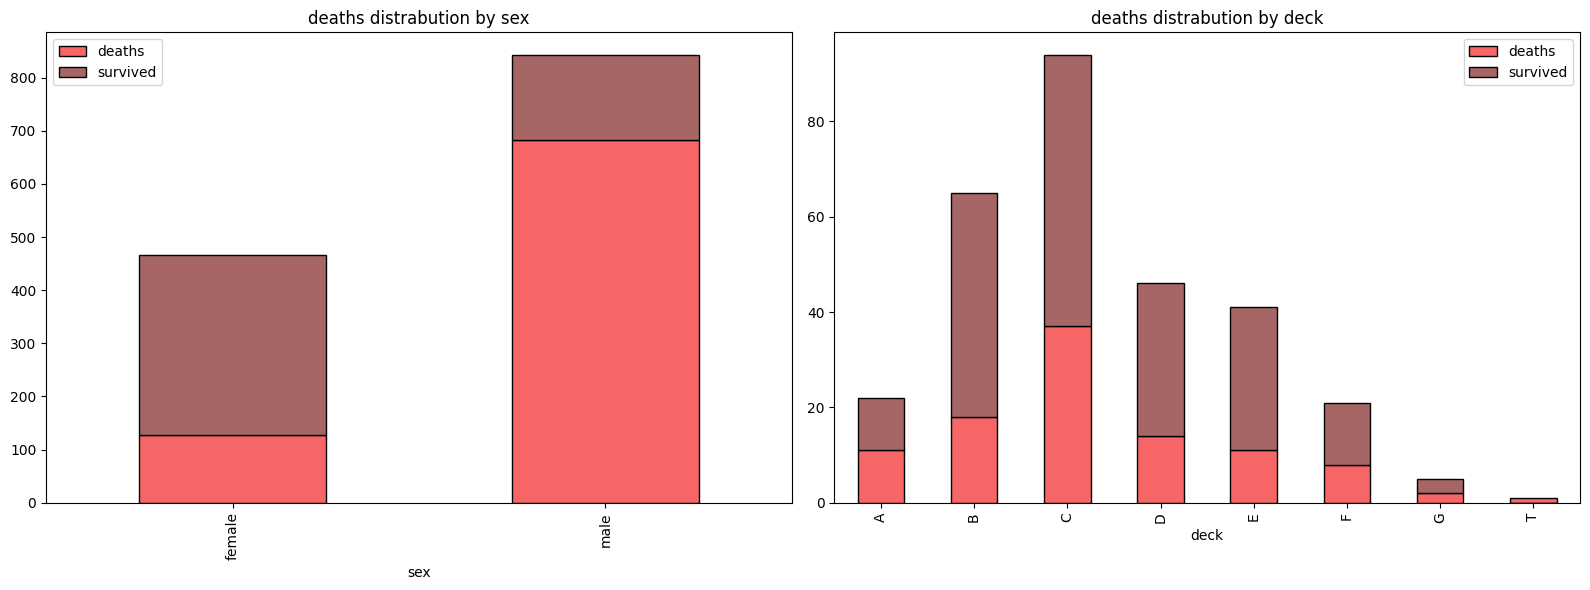

In [62]:
grouped_sex_df = (
    df.groupby("sex")
    .agg(
        survived=("survived", "sum"),
        total_members_of_sex=("survived", "size"),  # size נותן את כמות השורות בקבוצה
    )
    .reset_index()
).set_index("sex")

grouped_sex_df["deaths"] = (
    grouped_sex_df["total_members_of_sex"] - grouped_sex_df["survived"]
)

grouped_deck_df = (
    df.groupby("deck")
    .agg(
        survived=("survived", "sum"),
        total_members_of_sex=("survived", "size"),  # size נותן את כמות השורות בקבוצה
    )
    .reset_index()
).set_index("deck")

grouped_deck_df["deaths"] = (
    grouped_deck_df["total_members_of_sex"] - grouped_deck_df["survived"]
)

ig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. הגרף הראשון (גיל לפי מין) מנותב לאזור הציור השמאלי (axes[0])
grouped_deck_df[["deaths","survived"]].plot(
    kind="bar", stacked=True, color=["#F66666", "#A66666"], edgecolor="black",ax=axes[1]
)
axes[0].set_title("deaths distrabution by sex")

# 3. הגרף השני (גיל לפי סיפון) מנותב לאזור הציור הימני (axes[1])
# חילצתי את פקודת המיון למשתנה נפרד רק כדי שהקוד יהיה יותר קריא ומסודר
deck_order = sorted(df['deck'].dropna().unique())
grouped_sex_df[["deaths", "survived"]].plot(
    kind="bar", stacked=True, color=["#F66666", "#A66666"], edgecolor="black", ax=axes[0]
)
axes[1].set_title("deaths distrabution by deck")

# 4. סידור מרווחים אוטומטי והצגה
plt.tight_layout()
plt.show()

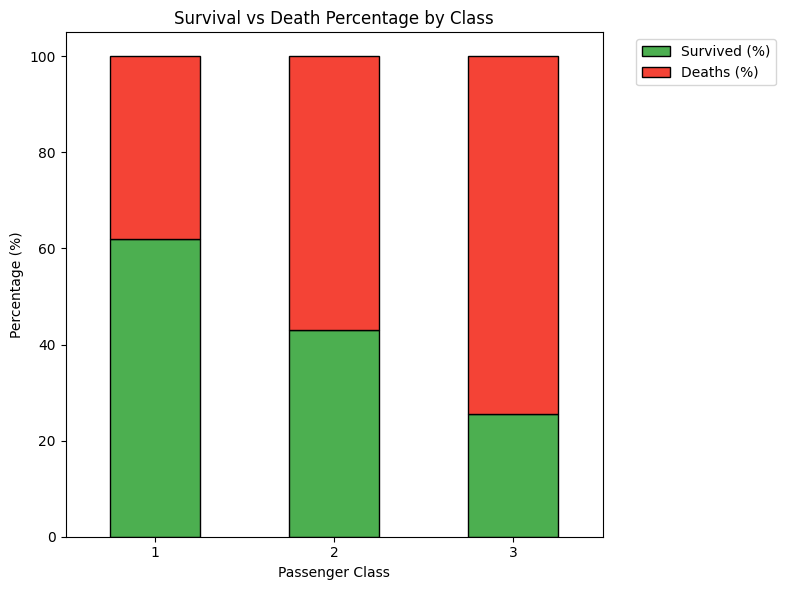

In [77]:
# 1. קיבוץ לפי מחלקה וספירת הנתונים
grouped_pclass_df = (
    df.groupby("pclass")
    .agg(
        survived=("survived", "sum"),
        total_passengers=("survived", "size"),  # שיניתי את השם ל-passengers כי מדובר במחלקה
    )
    .reset_index()
)

# 2. חישוב המתים (מספר מוחלט - רק כדי שיהיה לנו)
grouped_pclass_df["deaths"] = (
    grouped_pclass_df["total_passengers"] - grouped_pclass_df["survived"]
)

# 3. הוספת חישוב האחוזים!
grouped_pclass_df["percent_survived"] = (grouped_pclass_df["survived"] / grouped_pclass_df["total_passengers"]) * 100
grouped_pclass_df["percent_deaths"] = (grouped_pclass_df["deaths"] / grouped_pclass_df["total_passengers"]) * 100

# 4. הפיכת השם לאינדקס לצורך הגרף
grouped_pclass_df = grouped_pclass_df.set_index("pclass")

# 5. ציור הגרף - הפעם נשתמש בעמודות האחוזים שיצרנו
# מכיוון שזה אחוזים שמסכמים ל-100, העמודות תמיד יגיעו לאותו גובה (100%)
grouped_pclass_df[["percent_survived", "percent_deaths"]].plot(
    kind="bar", stacked=True, color=["#4CAF50", "#F44336"], edgecolor="black", figsize=(8, 6)
)

# עיצוב הגרף
plt.ylabel("Percentage (%)")
plt.xlabel("Passenger Class")
plt.title("Survival vs Death Percentage by Class")
plt.xticks(rotation=0) # דואג שהמספרים של המחלקות יהיו ישרים ולא נטויים
plt.legend(["Survived (%)", "Deaths (%)"], bbox_to_anchor=(1.05, 1), loc='upper left') # הזזת המקרא החוצה שלא יסתיר

# פקודה שמונעת חיתוך של המקרא או הכותרות
plt.tight_layout()
plt.show()

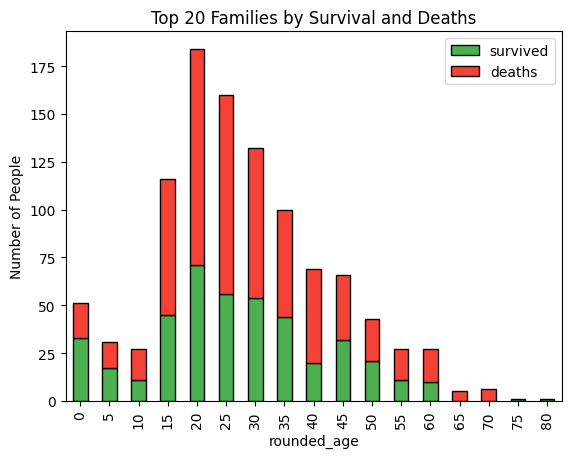

In [93]:
df["rounded_age"] = (df.age // 5).astype("Int64") * 5
grouped_age_df = (
    df.groupby("rounded_age")
    .agg(
        survived=("survived", "sum"),
        total_members_of_family=("survived", "size"),  
    )
)

# 2. חישוב המתים
grouped_age_df["deaths"] = (
    grouped_age_df["total_members_of_family"] - grouped_age_df["survived"]
)


# 4. ציור הגרף (לקחת את ה-20 הראשונים)
# הערה: עדיף להציג את "survived" ו-"deaths" כדי שהם ישלימו ביחד ל-total, 
# אם תציג את total ו-deaths אחד על השני ה-total יבלע את ה-deaths או יציג מספרים כפולים.
grouped_age_df[["survived", "deaths"]].plot(
    kind="bar", stacked=True, color=["#4CAF50", "#F44336"], edgecolor="black"
)

plt.ylabel("Number of People")
plt.title("Top 20 Families by Survival and Deaths")
plt.show()